# LLM experiments — Week 8 BBO

Systematic comparison of **prompt patterns** (zero-shot / few-shot / chain-of-thought), **domain context** on/off, and **temperature** on LLM-suggested queries vs surrogate predictions.

**Prerequisites:** `pip install openai anthropic pandas` (see [requirements.txt](../requirements.txt)). Set `OPENAI_API_KEY` or `ANTHROPIC_API_KEY` in the environment.

Logs append to `data/results/week_8/llm_experiments.json`.

In [4]:
import os
from getpass import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
    print("Key set in this session.")
else:
    print("OPENAI_API_KEY already set.")

Key set in this session.


In [5]:
import os
import sys
from pathlib import Path

root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import numpy as np
from src.data import FunctionData, DATA_DIR, initialize_all_weeks
from src.llm_advisor import (
    LLMClient,
    PromptBuilder,
    ResponseParser,
    ExperimentLogger,
    surrogate_mean_at,
)

np.random.seed(42)
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
n_weeks = initialize_all_weeks(functions)
print(f"Loaded {n_weeks} weeks of results into FunctionData.")
for i, f in functions.items():
    _, yb = f.get_best()
    print(f"  F{i}: {f.n_dims}D, n={f.n_samples}, best_y={yb:.6g}")


INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results
Loading weeks: [1, 2, 3, 4, 5, 6, 7, 8]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_4
✓ Week 4: Updated 8 functions
✓ Loaded Week 5 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_5
✓ Week 5: Updated 8 functions
✓ Loaded Week 6 from /home/robin/Personal_Development/Capst

## Experiment grid

- **Reduce cost:** set `FUNCTION_IDS` to a subset (e.g. `[2, 6, 7, 8]`).
- **Provider:** `PROVIDER = "openai"` or `"anthropic"`.
- Optional: `os.environ["OPENAI_MODEL"] = "gpt-4o-mini"` (default) or override.

In [6]:
PROVIDER = os.environ.get("LLM_PROVIDER", "openai")  # or "anthropic"
# All 8 functions = 192 API calls with default grid; subset for cheaper runs:
FUNCTION_IDS = list[2,6,7,8](range(1, 9))  # e.g. [2, 6, 7, 8] to save calls

EXPERIMENT_GRID = {
    "prompt_types": ["zero_shot", "few_shot", "chain_of_thought"],
    "temperatures": [0.0, 0.3, 0.7, 1.0],
    "domain_context": [True, False],
}
TOP_P = 0.95
TOP_K = 40  # Anthropic only; ignored for OpenAI
MAX_TOKENS = 500
MAX_POINTS_FEW_SHOT = None  # None = all points; int = cap for context-window experiments

def surrogate_kind_for(fid: int) -> str:
    return "svr" if fid == 8 else "gp"

n_calls = len(FUNCTION_IDS) * len(EXPERIMENT_GRID["prompt_types"]) * len(EXPERIMENT_GRID["temperatures"]) * len(EXPERIMENT_GRID["domain_context"])
print(f"Planned API calls (approx): {n_calls}")


Planned API calls (approx): 192


## Run experiments

Re-run after changing the grid; logs are cumulative unless you delete `llm_experiments.json`.

In [7]:
def build_prompt(pb: PromptBuilder, ptype: str, fd: FunctionData, use_dom: bool) -> str:
    if ptype == "zero_shot":
        return pb.zero_shot(fd, use_domain=use_dom)
    if ptype == "few_shot":
        return pb.few_shot(fd, use_domain=use_dom, max_points=MAX_POINTS_FEW_SHOT)
    if ptype == "chain_of_thought":
        return pb.chain_of_thought(fd, use_domain=use_dom, max_points=MAX_POINTS_FEW_SHOT)
    raise ValueError(ptype)


logger = ExperimentLogger()
parser = ResponseParser()
pb = PromptBuilder()

try:
    client = LLMClient(provider=PROVIDER)
except Exception as e:
    client = None
    print("LLMClient not available:", e)
    print("Set API key and install SDK, then re-run this cell.")

if client is not None:
    for fid in FUNCTION_IDS:
        fd = functions[fid]
        sk = surrogate_kind_for(fid)
        for ptype in EXPERIMENT_GRID["prompt_types"]:
            for temp in EXPERIMENT_GRID["temperatures"]:
                for use_dom in EXPERIMENT_GRID["domain_context"]:
                    prompt = build_prompt(pb, ptype, fd, use_dom)
                    resp = client.complete(
                        prompt,
                        temperature=float(temp),
                        top_p=TOP_P,
                        top_k=TOP_K,
                        max_tokens=MAX_TOKENS,
                    )
                    q, ok, msg = parser.parse(resp.text, fd.n_dims)
                    pred = None
                    if ok and q is not None:
                        pred = surrogate_mean_at(fd, q, surrogate_kind=sk, use_ard=True)
                    rec = {
                        "func_id": fid,
                        "prompt_type": ptype,
                        "domain_context": use_dom,
                        "model": resp.model,
                        "temperature": temp,
                        "top_p": TOP_P,
                        "top_k": TOP_K if PROVIDER == "anthropic" else None,
                        "max_tokens": MAX_TOKENS,
                        "prompt_text": prompt,
                        "prompt_tokens": resp.prompt_tokens,
                        "response_text": resp.text,
                        "response_tokens": resp.completion_tokens,
                        "parsed_query": q.tolist() if ok and q is not None else None,
                        "parse_success": ok,
                        "parse_message": msg,
                        "surrogate_pred_at_query": pred,
                    }
                    logger.append(rec)
                    st = "OK" if ok else "FAIL"
                    print(f"F{fid} {ptype} T={temp} dom={use_dom} -> {st}")
    print(f"Logged {len(logger.records)} total records to {logger.log_path}")


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F1 zero_shot T=0.0 dom=True -> OK


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F1 zero_shot T=0.0 dom=False -> OK


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

F7 chain_of_thought T=0.7 dom=False -> OK


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F7 chain_of_thought T=1.0 dom=True -> OK


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F7 chain_of_thought T=1.0 dom=False -> OK
F8 zero_shot T=0.0 dom=True -> OK
F8 zero_shot T=0.0 dom=False -> OK
F8 zero_shot T=0.3 dom=True -> OK
F8 zero_shot T=0.3 dom=False -> OK
F8 zero_shot T=0.7 dom=True -> OK
F8 zero_shot T=0.7 dom=False -> OK
F8 zero_shot T=1.0 dom=True -> OK
F8 zero_shot T=1.0 dom=False -> OK
F8 few_shot T=0.0 dom=True -> OK
F8 few_shot T=0.0 dom=False -> OK
F8 few_shot T=0.3 dom=True -> OK
F8 few_shot T=0.3 dom=False -> OK
F8 few_shot T=0.7 dom=True -> OK
F8 few_shot T=0.7 dom=False -> OK
F8 few_shot T=1.0 dom=True -> OK
F8 few_shot T=1.0 dom=False -> OK
F8 chain_of_thought T=0.0 dom=True -> OK
F8 chain_of_thought T=0.0 dom=False -> OK
F8 chain_of_thought T=0.3 dom=True -> OK
F8 chain_of_thought T=0.3 dom=False -> OK
F8 chain_of_thought T=0.7 dom=True -> OK
F8 chain_of_thought T=0.7 dom=False -> OK
F8 chain_of_thought T=1.0 dom=True -> OK
F8 chain_of_thought T=1.0 dom=False -> OK
Logged 192 total records to /home/robin/Personal_Development/Capstone-Project-ML-A

## Analysis

Reload the log and summarise: parse rate, temperature vs diversity, domain on/off, token usage vs dimension.

Records: 192

Parse success rate by temperature:
temperature
0.0    1.0
0.3    1.0
0.7    1.0
1.0    1.0
Name: parse_success, dtype: float64

Parse success rate by prompt_type:
prompt_type
chain_of_thought    1.0
few_shot            1.0
zero_shot           1.0
Name: parse_success, dtype: float64

Mean coord std (diversity proxy) by temperature:
temperature
0.0    0.083160
0.3    0.079756
0.7    0.094705
1.0    0.092923
Name: coord_std, dtype: float64


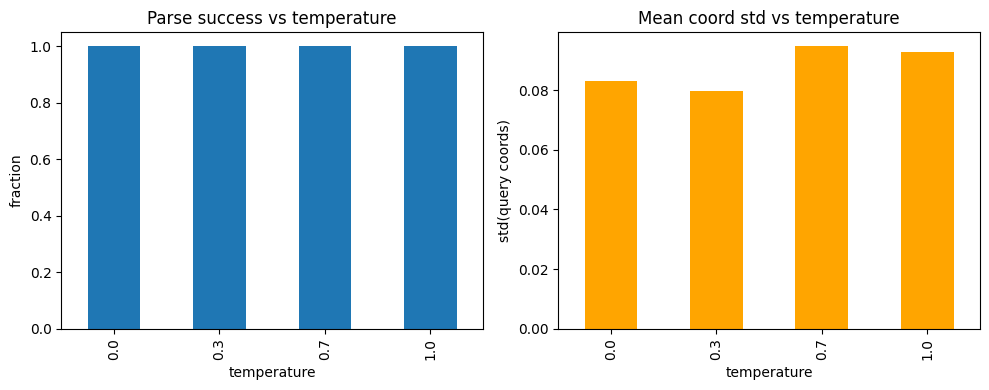


Mean prompt_tokens by function (context pressure):
func_id
1     340.333333
2     368.333333
3     516.000000
4     867.666667
5     676.500000
6     786.833333
7    1104.833333
8    1688.000000
Name: prompt_tokens, dtype: float64


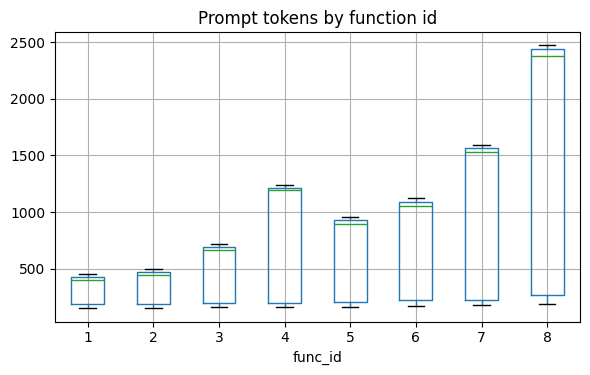

In [8]:
import json
from pathlib import Path

log_path = DATA_DIR / "results" / "week_8" / "llm_experiments.json"
if not log_path.exists():
    print("No log yet. Run the experiment cell first.")
else:
    with open(log_path, "r", encoding="utf-8") as f:
        records = json.load(f)
    print(f"Records: {len(records)}")

    import pandas as pd

    df = pd.DataFrame(records)
    if len(df):
        print("\nParse success rate by temperature:")
        print(df.groupby("temperature")["parse_success"].mean())
        print("\nParse success rate by prompt_type:")
        print(df.groupby("prompt_type")["parse_success"].mean())

        def row_std(row):
            q = row.get("parsed_query")
            if not q or not isinstance(q, list):
                return np.nan
            return float(np.std(q))

        df["coord_std"] = df.apply(row_std, axis=1)
        print("\nMean coord std (diversity proxy) by temperature:")
        print(df.groupby("temperature")["coord_std"].mean())

        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        df.groupby("temperature")["parse_success"].mean().plot(kind="bar", ax=axes[0], title="Parse success vs temperature")
        axes[0].set_ylabel("fraction")
        df.groupby("temperature")["coord_std"].mean().plot(kind="bar", ax=axes[1], color="orange", title="Mean coord std vs temperature")
        axes[1].set_ylabel("std(query coords)")
        plt.tight_layout()
        plt.show()

        if "prompt_tokens" in df.columns:
            dim_map = {fid: functions[fid].n_dims for fid in range(1, 9)}
            df["n_dims"] = df["func_id"].map(dim_map)
            print("\nMean prompt_tokens by function (context pressure):")
            print(df.groupby("func_id")["prompt_tokens"].mean())
            fig2, ax2 = plt.subplots(figsize=(6, 4))
            df.boxplot(column="prompt_tokens", by="func_id", ax=ax2)
            ax2.set_title("Prompt tokens by function id")
            plt.suptitle("")
            plt.tight_layout()
            plt.show()


## Agreement with a surrogate baseline

For each function, compare the **median LLM suggestion** (successful parses, chain-of-thought, domain=True, T=0.3) to a **GP/SVR acquisition** suggestion from `weekly_workflow` strategies. Reuse the same acquisition helpers as in the weekly notebook.

In [9]:
from src.surrogates import GPSurrogate, SVMSurrogate
from src.acquisition import optimize_acquisition_with_regional_focus


def acquisition_baseline(fid: int, fd: FunctionData) -> np.ndarray:
    """Mirror W7-style settings for a rough surrogate comparison point."""
    if fid == 1:
        return np.array([0.25, 0.25])  # exploration placeholder; F1 manual in workflow
    if fid == 5:
        return np.array([0.05, 0.05, 0.05, 0.05])
    focus = fd.get_best()[0]
    if fid == 2:
        sur = GPSurrogate(noise=0.05, use_ard=False, optimize=True)
        sur.fit(fd.inputs, fd.outputs)
        x, _, _ = optimize_acquisition_with_regional_focus(
            sur, fd, acq_func="ei", xi=0.005, focus_region=np.array([0.70, 0.934]), focus_radius=0.03, n_random=1500, random_state=42
        )
        return x
    if fid == 8:
        sur = SVMSurrogate(C=5.0, epsilon=0.15, n_bootstrap=40)
        sur.fit(fd.inputs, fd.outputs)
        x, _, _ = optimize_acquisition_with_regional_focus(
            sur, fd, acq_func="ei", xi=0.003, focus_region=focus, focus_radius=0.02, n_random=20000, random_state=42
        )
        return x
    sur = GPSurrogate(use_ard=True, optimize=True)
    sur.fit(fd.inputs, fd.outputs)
    if fid == 4:
        x, _, _ = optimize_acquisition_with_regional_focus(
            sur, fd, acq_func="ei", xi=1e-4, focus_region=focus, focus_radius=0.01, n_random=1500, expand_search=False, random_state=42
        )
        return x
    if fid == 7:
        x, _, _ = optimize_acquisition_with_regional_focus(
            sur, fd, acq_func="ucb", beta=2.0, focus_region=np.array([0.070, 0.246, 0.464, 0.194, 0.366, 0.770]), focus_radius=0.05, n_random=10000, random_state=42
        )
        return x
    x, _, _ = optimize_acquisition_with_regional_focus(
        sur, fd, acq_func="ei", xi=0.003, focus_region=focus, focus_radius=0.03, n_random=1500, random_state=42
    )
    return x


log_path = DATA_DIR / "results" / "week_8" / "llm_experiments.json"
if log_path.exists():
    import json
    import pandas as pd

    with open(log_path, "r", encoding="utf-8") as f:
        _recs = json.load(f)
    df = pd.DataFrame(_recs)
    sub = df[
        (df["prompt_type"] == "chain_of_thought")
        & (df["domain_context"] == True)
        & (df["temperature"] == 0.3)
        & (df["parse_success"] == True)
    ].copy()
    print("L2 distance: median LLM query vs acquisition baseline (subset above)")
    for fid in FUNCTION_IDS:
        rows = sub[sub["func_id"] == fid]
        if rows.empty:
            print(f"  F{fid}: no rows")
            continue
        q_llm = np.array(rows.iloc[0]["parsed_query"], dtype=float)
        q_sur = acquisition_baseline(fid, functions[fid])
        dist = float(np.linalg.norm(q_llm - q_sur))
        print(f"  F{fid}: dist={dist:.4f}  LLM={q_llm}  sur={q_sur}")
else:
    print("No log for agreement section.")


L2 distance: median LLM query vs acquisition baseline (subset above)
  F1: dist=0.7906  LLM=[0.7 0.9]  sur=[0.25 0.25]
  F2: dist=0.0502  LLM=[0.75 0.95]  sur=[0.73  0.904]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F3: dist=0.1188  LLM=[0.5 0.5 0.5]  sur=[0.414322   0.41994    0.48086907]
  F4: dist=0.0351  LLM=[0.43  0.4   0.37  0.425]  sur=[0.406785 0.398733 0.344862 0.417478]
  F5: dist=1.8990  LLM=[0.9995 0.9998 0.9997 0.999 ]  sur=[0.05 0.05 0.05 0.05]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F6: dist=0.5876  LLM=[0.7 0.5 0.6 0.8 0.3]  sur=[0.248      0.28105952 0.412      0.79085814 0.06      ]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F7: dist=0.3944  LLM=[0.15 0.3  0.5  0.6  0.4  0.8 ]  sur=[0.12       0.196      0.414      0.244      0.316      0.74821506]
  F8: dist=0.5687  LLM=[0.3 0.4 0.5 0.2 0.7 0.6 0.3 0.5]  sur=[0.111909   0.231      0.10226195 0.152      0.836      0.364
 0.156      0.56350395]


## Final W8 query selection (template)

- **F1 / F5:** manual overrides (e.g. F5 diagnostic `[0.05, 0.05, 0.05, 0.05]`).
- **Others:** if LLM vs surrogate L2 distance `< 0.05`, prefer consensus; else prefer surrogate unless LLM reasoning is stronger (document in report).

Paste chosen vectors into `weekly_workflow.ipynb` Section 2.

In [ ]:
# Example placeholder — replace after reviewing experiment log and report
W8_QUERIES = {
    1: np.array([0.25, 0.25]),
    2: np.array([0.72, 0.12]),
    3: np.array([0.40, 0.39, 0.47]),
    4: np.array([0.420, 0.410, 0.350, 0.430]),
    5: np.array([0.05, 0.05, 0.05, 0.05]),
    6: np.array([0.22, 0.28, 0.46, 0.80, 0.00]),
    7: np.array([0.10, 0.18, 0.53, 0.13, 0.34, 0.74]),
    8: np.array([0.12, 0.20, 0.11, 0.12, 0.87, 0.33, 0.12, 0.56]),
}
for k, v in W8_QUERIES.items():
    print(f"F{k}: {v}")
